Работа классификации обнаружения аномалий

In [ ]:
# Загрузка библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Загрузка даннных

df = pd.read_csv('data/mpi_roof.csv', parse_dates=['Date Time'], index_col='Date Time')
n_rows, n_cols = df.shape
print(f'Размер выборки: {n_rows} строк на {n_cols} столбцов')

Размер выборки: 1051920 строк на 20 столбцов


In [22]:
from statsmodels.tsa.stattools import adfuller, kpss

def check_stationarity(series, alpha=0.05, name='Ряд'):
    """
    Выполняет ADF и KPSS тесты для проверки стационарности ряда
    """
    print(f'Результаты проверки для: {name}')

    # --- ADF тест ---
    adf_result = adfuller(series, maxlag=20, autolag='AIC')
    adf_pvalue = adf_result[1]
    print(f'  ADF: p-value = {adf_pvalue:.5f}')

    # --- KPSS тест ---
    kpss_result = kpss(series, regression='c', nlags=20)
    kpss_pvalue = kpss_result[1]
    print(f'  KPSS: p-value = {kpss_pvalue:.5f}')

    # --- Интерпретация ---
    adf_stationary = adf_pvalue < alpha
    kpss_stationary = kpss_pvalue > alpha

    if adf_stationary and kpss_stationary:
        print(f'Вывод: Ряд "{name}" Стационарен')
    elif (not adf_stationary) and (not kpss_stationary):
        print(f'Вывод: Ряд "{name}" Нестационарен (единичный корень)')
    elif adf_stationary and (not kpss_stationary):
        print(f'Вывод: Ряд "{name}" Нестационарен (возможно, детерминированный тренд)')
    else:
        print(f'Вывод: Данных недостаточно для вывода о стационарности ряда "{name}"')

check_stationarity(df['T (degC)'], name='Температура'); print('\n')
check_stationarity(df['max. wv (m/s)'], name='Порыв ветра'); print('\n')
check_stationarity(df['rain (mm)'], name='Осадки'); print('\n')
check_stationarity(df['SWDR (W/m²)'], name='Солнечная радиация')

Результаты проверки для: Температура
  ADF: p-value = 0.00000
  KPSS: p-value = 0.01000
Вывод: Ряд "Температура" Нестационарен (возможно, детерминированный тренд)


Результаты проверки для: Порыв ветра
  ADF: p-value = 0.00000
  KPSS: p-value = 0.01000
Вывод: Ряд "Порыв ветра" Нестационарен (возможно, детерминированный тренд)


Результаты проверки для: Осадки
  ADF: p-value = 0.00000
  KPSS: p-value = 0.08180
Вывод: Ряд "Осадки" Стационарен


Результаты проверки для: Солнечная радиация
  ADF: p-value = 0.00000
  KPSS: p-value = 0.01000
Вывод: Ряд "Солнечная радиация" Нестационарен (возможно, детерминированный тренд)


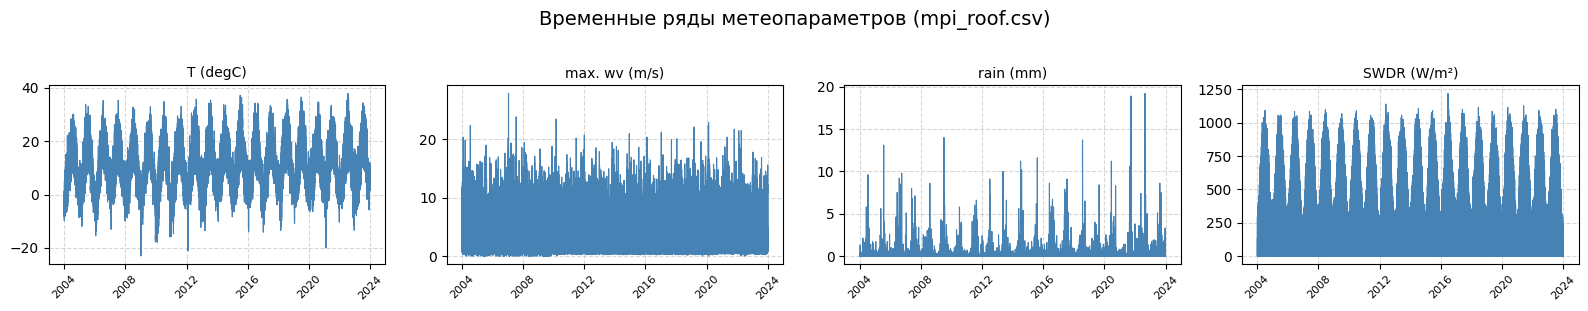

In [23]:
features_to_plot = ['T (degC)', 'max. wv (m/s)', 'rain (mm)', 'SWDR (W/m²)']
n_features = len(features_to_plot)
n_cols_plot = 4
n_rows_plot = (n_features + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 3 * n_rows_plot))
axes = axes.flatten()
for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    ax.plot(df.index, df[feature], linewidth=0.8, color='steelblue')
    ax.set_title(feature, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Временные ряды метеопараметров (mpi_roof.csv)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

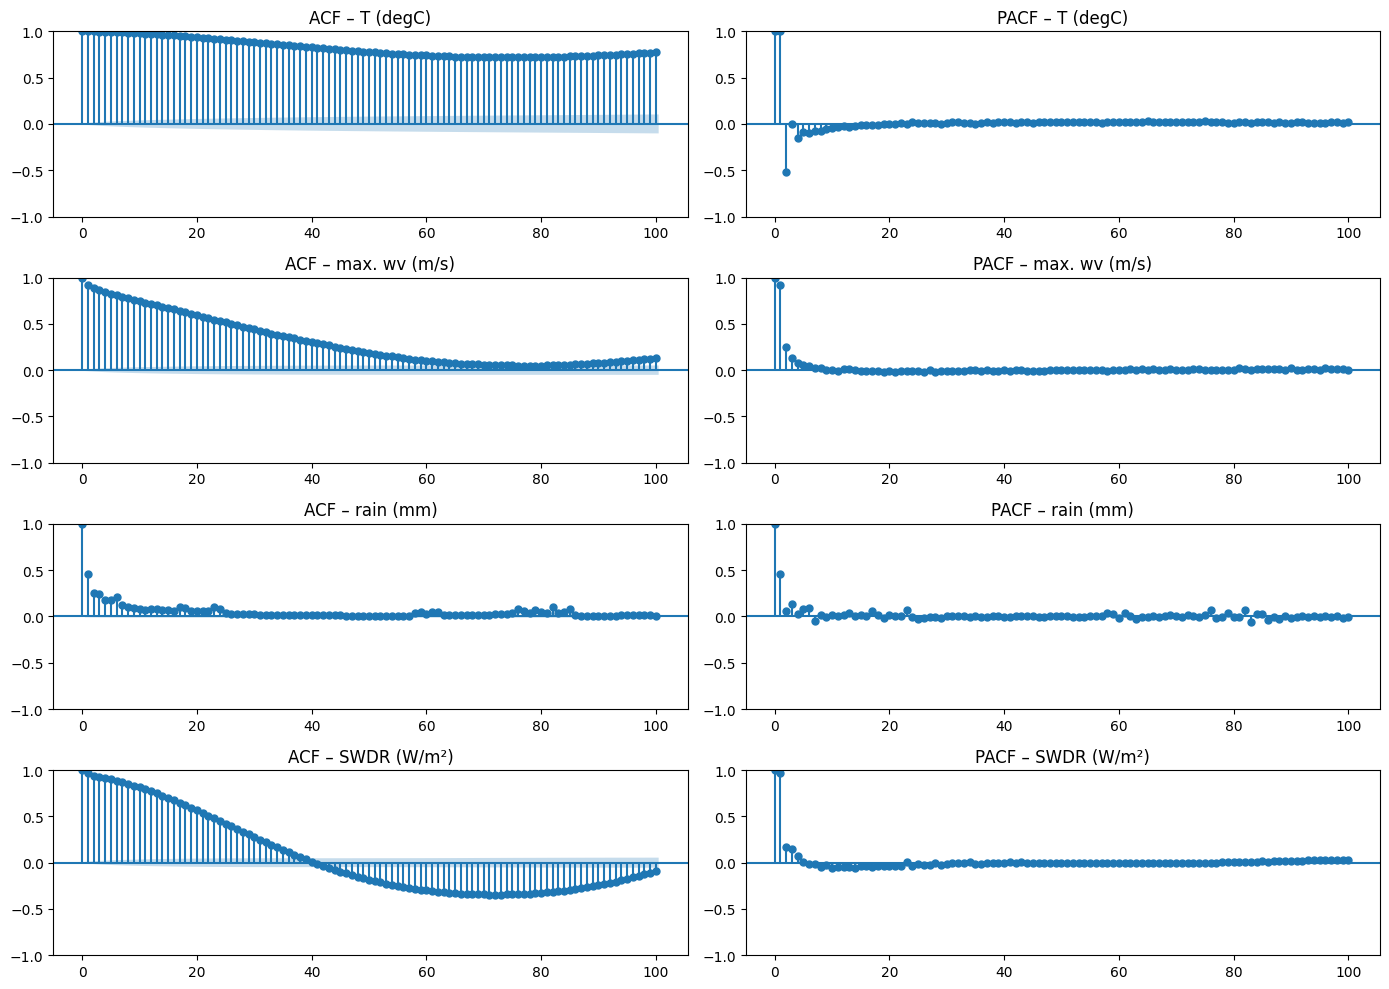

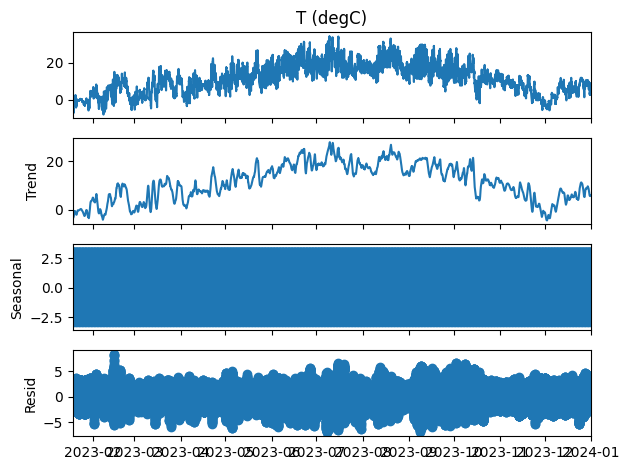

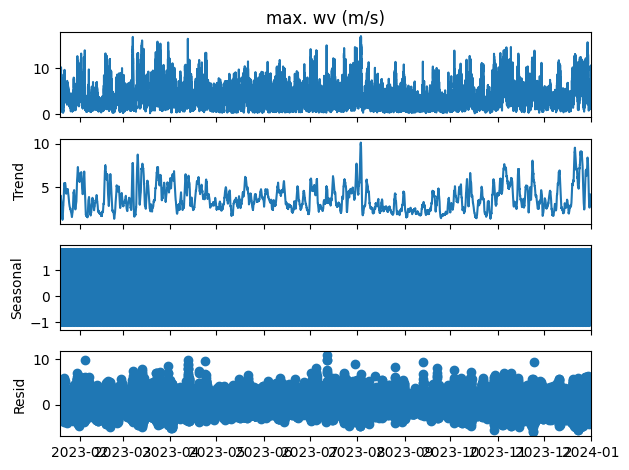

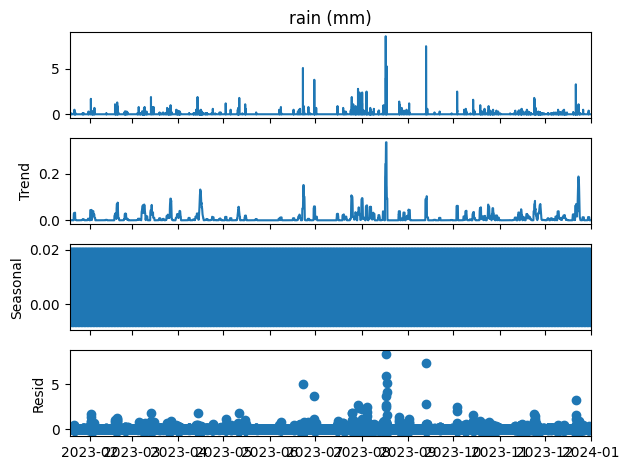

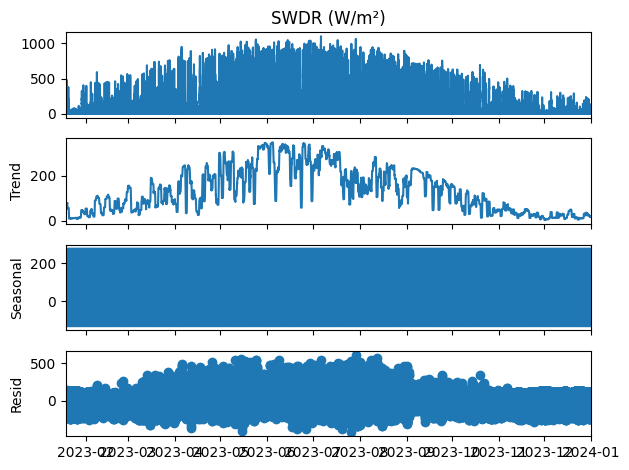

In [24]:
df_sample = df.iloc[-50000:]

series = ['T (degC)', 'max. wv (m/s)', 'rain (mm)', 'SWDR (W/m²)']
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 10))

for i, col in enumerate(series):
    data = df_sample[col].dropna()
    plot_acf(data, lags=100, ax=axes[i, 0])
    axes[i, 0].set_title(f'ACF – {col}')
    plot_pacf(data, lags=100, ax=axes[i, 1], method='ywm')
    axes[i, 1].set_title(f'PACF – {col}')

plt.tight_layout()
plt.show()

cols_to_decomp = ['T (degC)', 'max. wv (m/s)', 'rain (mm)', 'SWDR (W/m²)']

for col in cols_to_decomp:
    decomp = seasonal_decompose(df_sample[col].dropna(), model='additive', period=144)
    decomp.plot()
    plt.suptitle('')
    plt.show()

In [25]:
# Выбросы
features_out = ['T (degC)', 'max. wv (m/s)', 'rain (mm)']
mask = pd.Series(True, index=df.index)

# Копируем данные для обработки
df_clean = df[mask].copy()

removed_total = 0
while True:
    mask = pd.Series(True, index=df_clean.index)
    for col in features_out:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask &= (df_clean[col] >= lower) & (df_clean[col] <= upper)

    new_len = mask.sum()
    if new_len == len(df_clean):
        break
    removed_total += len(df_clean) - new_len
    df_clean = df_clean[mask].copy()

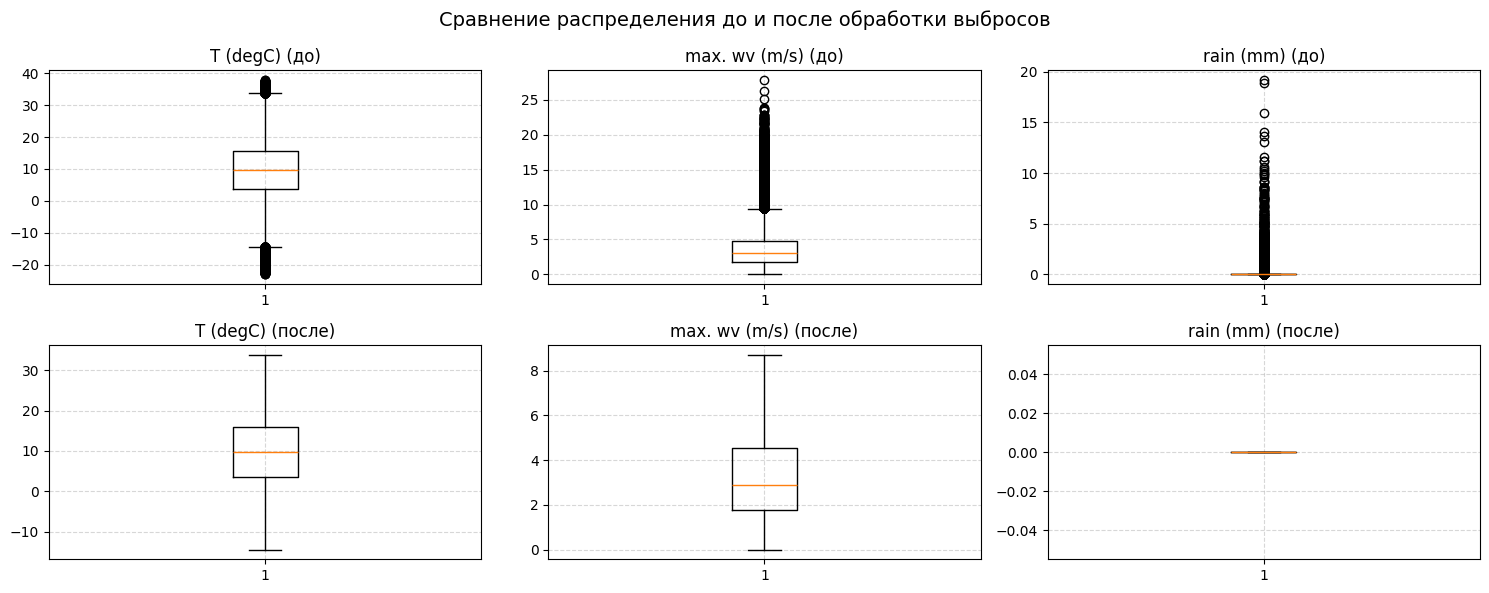

In [26]:
fig, axes = plt.subplots(2, len(features_out), figsize=(15, 6))
fig.suptitle('Сравнение распределения до и после обработки выбросов', fontsize=14)

for i, col in enumerate(features_out):
    # До обработки (оригинальные данные)
    axes[0, i].boxplot(df[col].dropna(), vert=True)
    axes[0, i].set_title(f'{col} (до)')
    axes[0, i].grid(True, linestyle='--', alpha=0.5)

    # После обработки (df_clean)
    axes[1, i].boxplot(df_clean[col].dropna(), vert=True)
    axes[1, i].set_title(f'{col} (после)')
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [27]:
df_clean['wd_sin'] = np.sin(np.radians(df_clean['wd (deg)']))
df_clean['wd_cos'] = np.cos(np.radians(df_clean['wd (deg)']))
df_clean.drop('wd (deg)', axis=1, inplace=True)

# Масштабирование
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(scaled_data, columns=df_clean.columns, index=df_clean.index)

In [28]:
data = df_scaled.copy()

data = data.iloc[:200000]
# Lag features (метод 1)
for lag in [1, 3, 6, 12, 24, 48]:
    data[f'T_lag_{lag}'] = data['T (degC)'].shift(lag)
    data[f'SWDR_lag_{lag}'] = data['SWDR (W/m²)'].shift(lag)
    data[f'wind_lag_{lag}'] = data['max. wv (m/s)'].shift(lag)
    data[f'rain_lag_{lag}'] = data['rain (mm)'].shift(lag)

# Rolling statistics (метод 2)
for win in [6, 12, 24]:
    # Температура
    data[f'T_roll_mean_{win}'] = data['T (degC)'].rolling(win).mean()
    data[f'T_roll_std_{win}'] = data['T (degC)'].rolling(win).std()
    # SWDR
    data[f'SWDR_roll_mean_{win}'] = data['SWDR (W/m²)'].rolling(win).mean()
    data[f'SWDR_roll_std_{win}'] = data['SWDR (W/m²)'].rolling(win).std()
    data[f'SWDR_roll_min_{win}'] = data['SWDR (W/m²)'].rolling(win).min()
    data[f'SWDR_roll_max_{win}'] = data['SWDR (W/m²)'].rolling(win).max()
    # Ветер
    data[f'wind_roll_mean_{win}'] = data['max. wv (m/s)'].rolling(win).mean()
    data[f'wind_roll_std_{win}'] = data['max. wv (m/s)'].rolling(win).std()
    # Осадки
    data[f'rain_roll_mean_{win}'] = data['rain (mm)'].rolling(win).mean()
    data[f'rain_roll_std_{win}'] = data['rain (mm)'].rolling(win).std()

#Min/max (метод 3)
for win in [12, 24]:
    data[f'T_min_{win}'] = data['T (degC)'].rolling(win).min()
    data[f'T_max_{win}'] = data['T (degC)'].rolling(win).max()

data['SWDR_diff'] = data['SWDR (W/m²)'].diff()

data.dropna(inplace=True)

In [29]:
common_idx = data.index.intersection(df_clean.index)
data = data.loc[common_idx]
df_clean_aligned = df_clean.loc[common_idx]

In [30]:
n_train = int(0.7 * len(data))
train_indices = data.index[:n_train]

temp_diff_train = df_clean_aligned.loc[train_indices, 'T (degC)'].diff().abs()
threshold_temp = temp_diff_train.quantile(0.95)       # 0.8C примерно

wind_train = df_clean_aligned.loc[train_indices, 'max. wv (m/s)']
threshold_wind = wind_train.quantile(0.95)

rain_train = df_clean_aligned.loc[train_indices, 'rain (mm)']
threshold_rain = rain_train.quantile(0.95)            # ~0.3 мм

swdr_train = df_clean_aligned.loc[train_indices, 'SWDR (W/m²)']
threshold_swdr = swdr_train.quantile(0.95)   # примерно 800-900 Вт/м²

# Можно также добавить условие на резкий скачок SWDR
swdr_diff = df_clean_aligned['SWDR (W/m²)'].diff().abs()
anomaly_swdr = (swdr_diff > threshold_swdr).astype(int)   # или (df_clean_aligned['SWDR (W/m²)'] > threshold_swdr)


In [31]:
temp_diff = df_clean_aligned['T (degC)'].diff().abs()
anomaly_temp = (temp_diff > threshold_temp).astype(int)
anomaly_wind = (df_clean_aligned['max. wv (m/s)'] > threshold_wind).astype(int)
anomaly_rain = (df_clean_aligned['rain (mm)'] > threshold_rain).astype(int)
y_anomaly = ((anomaly_temp + anomaly_wind + anomaly_rain +anomaly_swdr) >= 1).astype(int)

print(f"Доля аномалий: {y_anomaly.mean():.3f}")

Доля аномалий: 0.099


In [32]:
horizon = 18   # 3 часа
y_target = y_anomaly.shift(-horizon).dropna()
X_target = data.iloc[:-horizon]   # обрезаем X соответственно
X_target, y_target = X_target.align(y_target, join='inner', axis=0)

# Разделение на train/val/test (в хронологическом порядке)
train_size = int(0.7 * len(X_target))
val_size = int(0.15 * len(X_target))
X_train = X_target.iloc[:train_size]
X_val   = X_target.iloc[train_size:train_size+val_size]
X_test  = X_target.iloc[train_size+val_size:]
y_train = y_target.iloc[:train_size]
y_val   = y_target.iloc[train_size:train_size+val_size]
y_test  = y_target.iloc[train_size+val_size:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Доля аномалий в тесте: {y_test.mean():.3f}")


Train: (139953, 80), Val: (29990, 80), Test: (29991, 80)
Доля аномалий в тесте: 0.088


In [33]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

metrics_rf = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_proba_rf)
}
print("Random Forest:")
print(f"accuracy: {metrics_rf['accuracy']:.4f}, precision: {metrics_rf['precision']:.4f}, recall: {metrics_rf['recall']:.4f}, f1: {metrics_rf['f1']:.4f}, roc_auc: {metrics_rf['roc_auc']:.4f}")

Random Forest:
accuracy: 0.9112, precision: 0.3438, recall: 0.0041, f1: 0.0082, roc_auc: 0.7595


In [34]:
time_steps = 72
def create_sequences(X, y, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X.iloc[i:i+time_steps].values)
        y_seq.append(y.iloc[i+time_steps])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_steps)
X_val_seq,   y_val_seq   = create_sequences(X_val,   y_val,   time_steps)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  time_steps)

In [35]:
#LSTM
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(time_steps, X_train.shape[1]), kernel_regularizer=l2(0.0005)),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20, batch_size=64, callbacks=[early_stop], verbose=1
)
y_proba_lstm = model_lstm.predict(X_test_seq).flatten()
y_pred_lstm = (y_proba_lstm >= 0.5).astype(int)
metrics_lstm = {
    'accuracy': accuracy_score(y_test_seq, y_pred_lstm),
    'precision': precision_score(y_test_seq, y_pred_lstm),
    'recall': recall_score(y_test_seq, y_pred_lstm),
    'f1': f1_score(y_test_seq, y_pred_lstm),
    'roc_auc': roc_auc_score(y_test_seq, y_proba_lstm)
}
print("LSTM:")
print(f"accuracy: {metrics_lstm['accuracy']:.6f}")
print(f"precision: {metrics_lstm['precision']:.6f}")
print(f"recall: {metrics_lstm['recall']:.6f}")
print(f"f1: {metrics_lstm['f1']:.6f}")
print(f"roc_auc: {metrics_lstm['roc_auc']:.6f}")

Epoch 1/20
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 117s 51ms/step - accuracy: 0.9049 - loss: 0.2986 - val_accuracy: 0.8677 - val_loss: 0.3532
Epoch 2/20
 243/2186 ━━━━━━━━━━━━━━━━━━━━ 1:35 49ms/step - accuracy: 0.9110 - loss: 0.2789

KeyboardInterrupt: 

In [ ]:
model_cnn = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(time_steps, X_train.shape[1])),
    MaxPooling1D(2),
    Conv1D(16, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_cnn.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq),
              epochs=20, batch_size=64, callbacks=[EarlyStopping(patience=5)], verbose=1)
y_proba_cnn = model_cnn.predict(X_test_seq).flatten()
y_pred_cnn = (y_proba_cnn >= 0.5).astype(int)
metrics_cnn = {
    'accuracy': accuracy_score(y_test_seq, y_pred_cnn),
    'precision': precision_score(y_test_seq, y_pred_cnn),
    'recall': recall_score(y_test_seq, y_pred_cnn),
    'f1': f1_score(y_test_seq, y_pred_cnn),
    'roc_auc': roc_auc_score(y_test_seq, y_proba_cnn)
}
print(f"accuracy: {metrics_cnn['accuracy']:.6f}, recall: {metrics_cnn['recall']:.6f}, roc_auc: {metrics_cnn['roc_auc']:.6f}")

In [ ]:
model_cnn = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(time_steps, X_train.shape[1])),
    MaxPooling1D(2),
    Conv1D(16, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_cnn.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq),
              epochs=20, batch_size=64, callbacks=[EarlyStopping(patience=5)], verbose=1)
y_proba_cnn = model_cnn.predict(X_test_seq).flatten()
y_pred_cnn = (y_proba_cnn >= 0.5).astype(int)
metrics_cnn = {
    'accuracy': accuracy_score(y_test_seq, y_pred_cnn),
    'precision': precision_score(y_test_seq, y_pred_cnn),
    'recall': recall_score(y_test_seq, y_pred_cnn),
    'f1': f1_score(y_test_seq, y_pred_cnn),
    'roc_auc': roc_auc_score(y_test_seq, y_proba_cnn)
}
print("CNN:")
print(f"accuracy: {metrics_cnn['accuracy']:.6f}, recall: {metrics_cnn['recall']:.6f}, roc_auc: {metrics_cnn['roc_auc']:.6f}")